In [22]:
import numpy as np
import scipy as sp
import matplotlib as mp
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [23]:
def sirSystem (g,b):

  def derivatives(t,y):
    S,I,R = y
    dSdt = -b *S*I
    dIdt = b*S*I - g*I
    dRdt = g*I
    return [dSdt,dIdt,dRdt]

  return derivatives


In [24]:
def costFunction(params, tData, yData, y0):
    g, b = params
    sir = sirSystem(g, b)
    solve = solve_ivp(sir, [tData[0], tData[-1]], y0, t_eval=tData)
    yModel = solve.y[1]
    J = np.sum((yModel - yData)**2)
    return J

In [25]:
data = np.loadtxt('/content/drive/MyDrive/Colab Notebooks/SIRdata.txt')

sData = data[:,0]
iData = data[:,1]
rData = data[:,2]
tData = np.arange(len(sData))
y0 = [sData[0],iData[0],rData[0]]

In [26]:
g = 0.4
b = 0.6
sir = sirSystem(g, b)
tSpan = [tData[0], tData[-1]]
solution = solve_ivp(sir, tSpan, y0, t_eval=tData)

sModel = solution.y[0]
iModel = solution.y[1]
rModel = solution.y[2]


In [27]:
guess = [0.1,0.7]

results = minimize(costFunction,guess,args = (tData, iData, y0), tol = 1e-6)


In [28]:
gOptimize, bOptimize = results.x
sirOptimize = sirSystem(gOptimize,bOptimize)
solutionOptimize = solve_ivp(sirOptimize,[tData[0],tData[-1]],y0,t_eval=tData)
sOptimize = solutionOptimize.y[0]
iOptimize = solutionOptimize.y[1]
rOptimize = solutionOptimize.y[2]

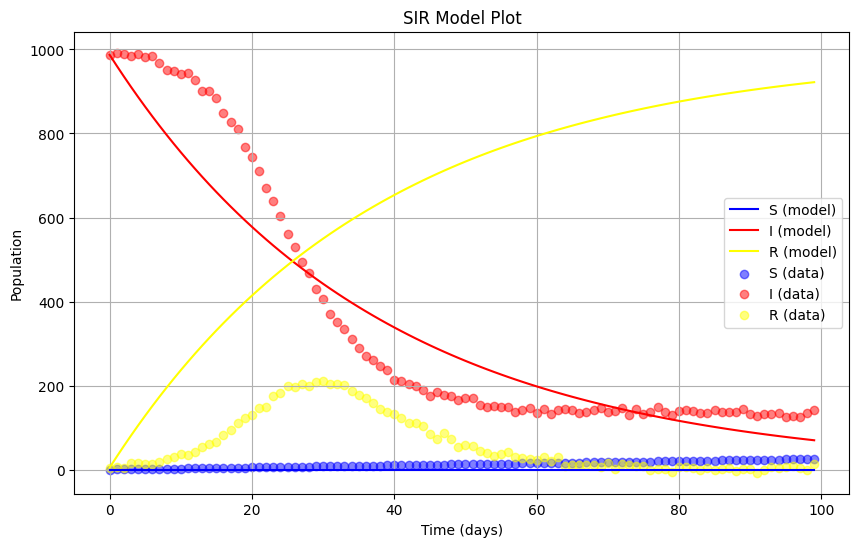

In [29]:
plt.figure(figsize=(10,6))

plt.plot(tData, sOptimize, label='S (model)', color='blue')
plt.plot(tData, iOptimize, label='I (model)', color='red')
plt.plot(tData, rOptimize, label='R (model)', color='yellow')

plt.scatter(tData, sData, color='blue', alpha=0.5, label='S (data)')
plt.scatter(tData, iData, color='red', alpha=0.5, label='I (data)')
plt.scatter(tData, rData, color='yellow', alpha=0.5, label='R (data)')

plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title('SIR Model Plot')
plt.legend()
plt.grid(True)
plt.show()


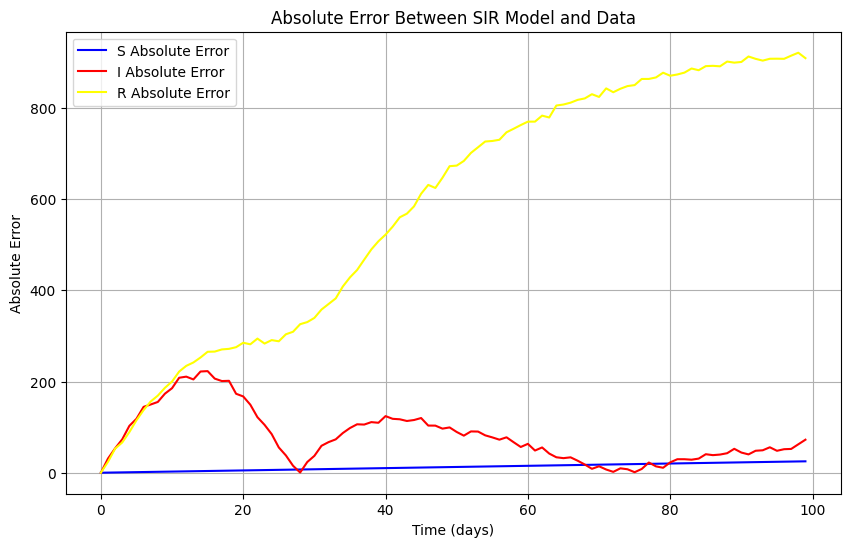

In [30]:
sError = np.abs(sOptimize - sData)
iError = np.abs(iOptimize - iData)
rError = np.abs(rOptimize - rData)

plt.figure(figsize=(10,6))
plt.plot(tData, sError, label='S Absolute Error', color='blue')
plt.plot(tData, iError, label='I Absolute Error', color='red')
plt.plot(tData, rError, label='R Absolute Error', color='yellow')

plt.xlabel('Time (days)')
plt.ylabel('Absolute Error')
plt.title('Absolute Error Between SIR Model and Data')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
gOptimize, bOptimize = results.x

print("Estimated SIR Parameters")
print(f"Gamma (removal rate) = {gOptimize:.6f}")
print(f"Beta (transmission coefficient) = {bOptimize:.6f}")

Estimated SIR Parameters
Gamma (removal rate) = 0.026774
Beta (transmission coefficient) = 0.700000
